In [7]:
import os
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
import numpy as np 
import joblib
import matplotlib.pyplot as plt

In [3]:
left_features_df = pd.read_csv("dataset/processed/left_hand_features.csv")
right_features_df = pd.read_csv("dataset/processed/right_hand_features.csv")


===== Left Hand SVM Evaluation =====
Accuracy      : 0.99
Precision     : 0.96
Recall        : 1.00
F1 Score      : 0.98
Weighted F1   : 0.99
ROC-AUC       : 1.00

Classification Report:
                precision    recall  f1-score   support

No Parkinson's       1.00      0.98      0.99        48
   Parkinson's       0.95      1.00      0.97        18

      accuracy                           0.98        66
     macro avg       0.97      0.99      0.98        66
  weighted avg       0.99      0.98      0.98        66

ROC-AUC (pooled): 1.00


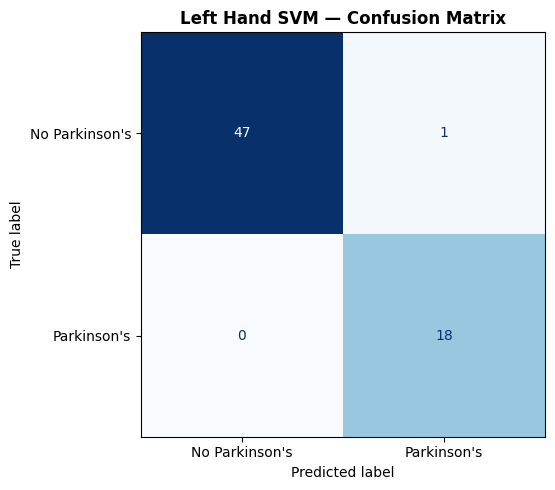


Uncertainty Rate: 0.02

Saved: models/left_svm.pkl

===== Right Hand SVM Evaluation =====
Accuracy      : 0.97
Precision     : 0.90
Recall        : 1.00
F1 Score      : 0.94
Weighted F1   : 0.97
ROC-AUC       : 1.00

Classification Report:
                precision    recall  f1-score   support

No Parkinson's       1.00      0.96      0.98        52
   Parkinson's       0.88      1.00      0.93        14

      accuracy                           0.97        66
     macro avg       0.94      0.98      0.96        66
  weighted avg       0.97      0.97      0.97        66

ROC-AUC (pooled): 0.99


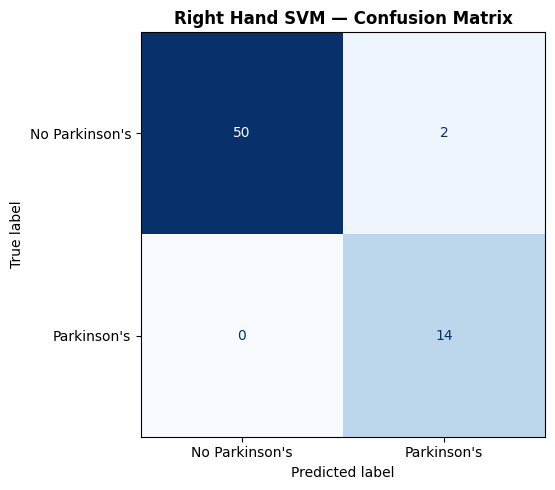


Uncertainty Rate: 0.03

Saved: models/right_svm.pkl


In [8]:
def evaluate_svm(df, hand_label):
    X = df.drop(columns=['target', 'patient_id', 'hand'])
    y = df['target']

    # Stratified k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='rbf',
            C=0.5,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=42
        ))
    ])

    # Cross-validated metrics
    scores = cross_validate(
        svm_pipeline, X, y, cv=skf,
        scoring={
            'accuracy':  'accuracy',
            'precision': 'precision',
            'recall':    'recall',
            'f1':        'f1',                          # binary F1
            'f1_weighted': 'f1_weighted',               # ← weighted F1 added here
            'roc_auc':   'roc_auc'
        }
    )

    print(f"\n===== {hand_label} Hand SVM Evaluation =====")
    print(f"Accuracy      : {np.mean(scores['test_accuracy']):.2f}")
    print(f"Precision     : {np.mean(scores['test_precision']):.2f}")
    print(f"Recall        : {np.mean(scores['test_recall']):.2f}")
    print(f"F1 Score      : {np.mean(scores['test_f1']):.2f}")
    print(f"Weighted F1   : {np.mean(scores['test_f1_weighted']):.2f}")  # ← printed here
    print(f"ROC-AUC       : {np.mean(scores['test_roc_auc']):.2f}")

    # Predictions for confusion matrix & report
    y_pred = cross_val_predict(svm_pipeline, X, y, cv=skf)
    y_prob = cross_val_predict(svm_pipeline, X, y, cv=skf, method='predict_proba')[:, 1]

    # ── Classification Report ──────────────────────────────
    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=["No Parkinson's", "Parkinson's"]))

    print(f"ROC-AUC (pooled): {roc_auc_score(y, y_prob):.2f}")

    # ── Confusion Matrix (visual) ──────────────────────────
    cm   = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Parkinson's", "Parkinson's"])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{hand_label} Hand SVM — Confusion Matrix", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"models/{hand_label.lower()}_confusion_matrix.png", dpi=150)
    plt.show()

    # ── Uncertainty Band ───────────────────────────────────
    def classify_with_uncertainty(p):
        if p < 0.40:
            return 0
        elif p > 0.50:
            return 1
        else:
            return -1  # unsure

    safe_preds   = np.array([classify_with_uncertainty(p) for p in y_prob])
    unsure_rate  = np.mean(safe_preds == -1)
    print(f"\nUncertainty Rate: {unsure_rate:.2f}")

    # ── Save Model ─────────────────────────────────────────
    model_path = f"models/{hand_label.lower()}_svm.pkl"
    svm_pipeline.fit(X, y)
    joblib.dump(svm_pipeline, model_path)
    print(f"\nSaved: {model_path}")


# Evaluate both hands
evaluate_svm(left_features_df,  "Left")
evaluate_svm(right_features_df, "Right")